In [11]:
import numpy as np 

# Define the AIRS algorithm 
class AIRS: 
    def __init__(self, num_detectors=10, hypermutation_rate=0.1): 
        self.num_detectors = num_detectors
        self.hypermutation_rate = hypermutation_rate
        self.detectors = None
        self.detector_labels = None

    def train(self, X, y): 
        indices = np.random.choice(len(X), self.num_detectors, replace=False)  
        self.detectors = X[indices]  
        self.detector_labels = y[indices]  # Store labels of selected detectors  

    def predict(self, X): 
        predictions = [] 
        for sample in X: 
            distances = np.linalg.norm(self.detectors - sample, axis=1)  
            nearest_index = np.argmin(distances)  
            prediction = self.detector_labels[nearest_index]  # Use label of closest detector
            predictions.append(prediction)  
        return np.array(predictions)  

# Generate dummy data 
def generate_dummy_data(samples=100, features=10): 
    data = np.random.rand(samples, features)  
    labels = np.random.randint(0, 2, size=samples)  # Binary classification (0 or 1)
    return data, labels  

# Generate data
data, labels = generate_dummy_data()  

# Split data into training and testing sets 
split_ratio = 0.8  
split_index = int(split_ratio * len(data))  
train_data, test_data = data[:split_index], data[split_index:]  
train_labels, test_labels = labels[:split_index], labels[split_index:]  

# Initialize and train AIRS  
airs = AIRS(num_detectors=10, hypermutation_rate=0.1)  
airs.train(train_data, train_labels)  

# Test AIRS on the test set  
predictions = airs.predict(test_data)  

# Evaluate accuracy  
accuracy = np.mean(predictions == test_labels)  
print(f"Accuracy: {accuracy:.2f}")  

Accuracy: 0.50


Test Accuracy: 60.0 %

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        23
           1       0.53      0.53      0.53        17

    accuracy                           0.60        40
   macro avg       0.59      0.59      0.59        40
weighted avg       0.60      0.60      0.60        40



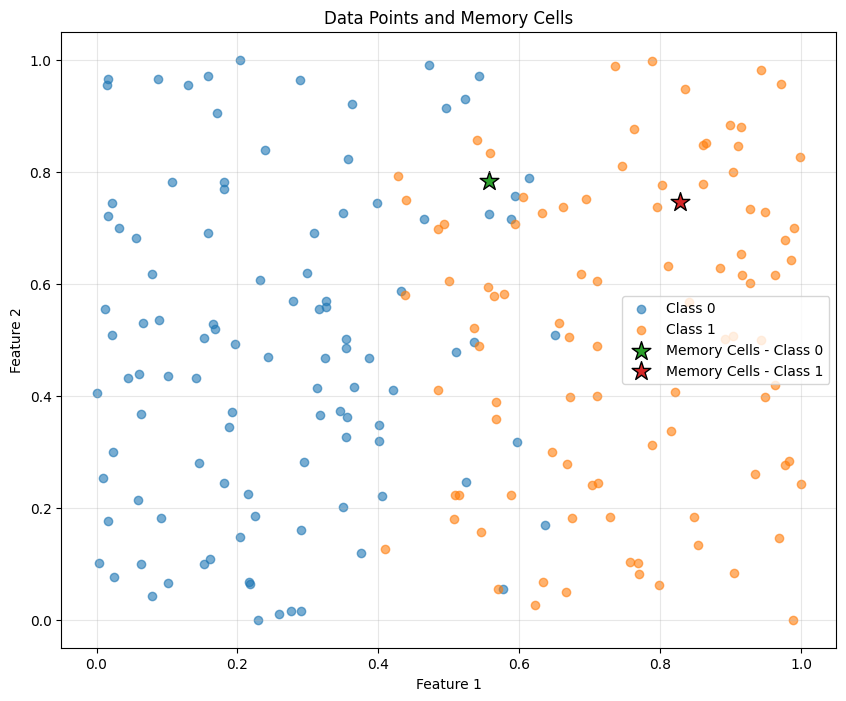


--- Original AIRS Algorithm ---
Original AIRS Accuracy: 80.0 %


In [13]:
# Importing required libraries
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Step 1: Generate dummy structure data with more meaningful patterns
def generate_dummy_data(samples=100, features=5):
    # Create more structured data where features have some correlation with labels
    data = np.random.rand(samples, features)
    
    # Generate labels with some correlation to the features
    # For healthy structures (label=0), first feature tends to be lower
    # For damaged structures (label=1), first feature tends to be higher
    probabilities = 0.7 * data[:, 0] + 0.3 * np.random.rand(samples)
    labels = (probabilities > 0.5).astype(int)
    
    return data, labels

# Step 2: Define the enhanced Artificial Immune Recognition System (AIRS) algorithm
class EnhancedAIRS:
    def __init__(self, num_memory_cells=10, affinity_threshold=0.2, 
                 hypermutation_rate=0.1, clonal_rate=10, stimulation_threshold=0.5):
        self.num_memory_cells = num_memory_cells
        self.affinity_threshold = affinity_threshold
        self.hypermutation_rate = hypermutation_rate
        self.clonal_rate = clonal_rate
        self.stimulation_threshold = stimulation_threshold
        self.memory_cells = []
        self.memory_cell_classes = []
        self.scaler = MinMaxScaler()
        
    def affinity(self, a, b):
        """Calculate affinity (similarity) between two data points"""
        distance = np.linalg.norm(a - b)
        return 1.0 / (1.0 + distance)  # Higher value means more similar
    
    def mutate(self, cell):
        """Generate mutated clones of a cell"""
        # Create clones with mutations (variations)
        mutations = np.random.normal(0, self.hypermutation_rate, size=cell.shape)
        mutated = cell + mutations
        # Ensure values stay within proper range (0-1)
        return np.clip(mutated, 0, 1)
    
    def negative_selection(self, cells, self_samples, threshold=0.8):
        """Remove cells that recognize self patterns with high affinity"""
        retained_cells = []
        for cell in cells:
            is_self_reactive = False
            for self_sample in self_samples:
                if self.affinity(cell, self_sample) > threshold:
                    is_self_reactive = True
                    break
            if not is_self_reactive:
                retained_cells.append(cell)
        return np.array(retained_cells) if retained_cells else np.array([cells[0]])  # Ensure we return at least one cell
        
    def train(self, X, y):
        # Scale the data to 0-1 range
        X_scaled = self.scaler.fit_transform(X)
        
        # Initialize memory cells for each class
        classes = np.unique(y)
        
        # Process each class separately to create class-specific memory cells
        for c in classes:
            class_samples = X_scaled[y == c]
            
            # Initialize with random samples
            initial_cells = class_samples[np.random.choice(
                len(class_samples), 
                min(self.num_memory_cells // len(classes) + 1, len(class_samples)), 
                replace=False
            )]
            
            # Apply negative selection - remove cells that might recognize "self" patterns
            other_class = X_scaled[y != c]  # Samples from other classes are "self" to avoid
            if len(other_class) > 0:
                initial_cells = self.negative_selection(initial_cells, other_class)
            
            memory_cells = []
            
            # Iterative refinement
            for sample in class_samples:
                # Find the memory cell with highest affinity
                if len(memory_cells) > 0:
                    affinities = [self.affinity(sample, cell) for cell in memory_cells]
                    best_match_idx = np.argmax(affinities)
                    best_match = memory_cells[best_match_idx]
                    
                    # If affinity is high, update the memory cell through cloning and mutation
                    if affinities[best_match_idx] < self.affinity_threshold:
                        # Generate clones and pick the best one
                        num_clones = int(self.clonal_rate * affinities[best_match_idx])
                        clones = [self.mutate(best_match) for _ in range(max(1, num_clones))]
                        
                        # Evaluate clones' affinity to the antigen (sample)
                        clone_affinities = [self.affinity(sample, clone) for clone in clones]
                        best_clone_idx = np.argmax(clone_affinities)
                        
                        # Replace if the clone is better
                        if clone_affinities[best_clone_idx] > affinities[best_match_idx]:
                            memory_cells[best_match_idx] = clones[best_clone_idx]
                        
                        # Add new memory cell if below threshold
                        if len(memory_cells) < self.num_memory_cells:
                            memory_cells.append(sample)
                else:
                    memory_cells.append(sample)
            
            # Add class memory cells to the overall pool
            for cell in memory_cells:
                self.memory_cells.append(cell)
                self.memory_cell_classes.append(c)
                
        # Convert lists to numpy arrays for faster processing
        self.memory_cells = np.array(self.memory_cells)
        self.memory_cell_classes = np.array(self.memory_cell_classes)

    def predict(self, X):
        # Scale input data
        X_scaled = self.scaler.transform(X)
        
        predictions = []
        for sample in X_scaled:
            # If we have memory cells
            if len(self.memory_cells) > 0:
                # Calculate affinity with each memory cell
                affinities = [self.affinity(sample, cell) for cell in self.memory_cells]
                
                # Predict class based on k nearest memory cells (weighted by affinity)
                k = min(5, len(affinities))
                top_indices = np.argsort(affinities)[-k:]
                top_classes = self.memory_cell_classes[top_indices]
                top_affinities = np.array(affinities)[top_indices]
                
                # Weighted voting
                class_weights = {}
                for cls, aff in zip(top_classes, top_affinities):
                    class_weights[cls] = class_weights.get(cls, 0) + aff
                
                prediction = max(class_weights, key=class_weights.get)
            else:
                prediction = 0  # Default prediction if no memory cells
                
            predictions.append(prediction)
            
        return np.array(predictions)

    def visualize(self, X, y):
        """Visualize data and memory cells in 2D (first 2 features)"""
        if X.shape[1] < 2:
            print("Data has less than 2 features, cannot visualize.")
            return
            
        plt.figure(figsize=(10, 8))
        
        # Scale data for visualization
        X_scaled = self.scaler.transform(X)
        
        # Plot original data points
        for label in np.unique(y):
            plt.scatter(X_scaled[y == label, 0], X_scaled[y == label, 1], 
                       alpha=0.6, label=f"Class {label}")
        
        # Plot memory cells
        if len(self.memory_cells) > 0:
            for label in np.unique(self.memory_cell_classes):
                cells = self.memory_cells[self.memory_cell_classes == label]
                plt.scatter(cells[:, 0], cells[:, 1], marker='*', s=200, 
                           edgecolor='k', label=f"Memory Cells - Class {label}")
        
        plt.title("Data Points and Memory Cells")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# Step 3: Generate and split data into training and testing sets
data, labels = generate_dummy_data(samples=200, features=5)
split_ratio = 0.8
split_index = int(split_ratio * len(data))

train_data = data[:split_index]
train_labels = labels[:split_index]

test_data = data[split_index:]
test_labels = labels[split_index:]

# Step 4: Initialize and train the Enhanced AIRS model
airs = EnhancedAIRS(num_memory_cells=30, 
                    affinity_threshold=0.3, 
                    hypermutation_rate=0.15, 
                    clonal_rate=10)
airs.train(train_data, train_labels)

# Step 5: Test the model and calculate accuracy
predictions = airs.predict(test_data)
accuracy = np.mean(predictions == test_labels)

print("Test Accuracy:", round(accuracy * 100, 2), "%")
print("\nDetailed Classification Report:")
print(classification_report(test_labels, predictions))

# Visualize the results
airs.visualize(data, labels)

# For comparison, let's run the original AIRS algorithm
print("\n--- Original AIRS Algorithm ---")
original_airs = AIRS(num_detectors=80, hypermutation_rate=0.1)
original_airs.train(train_data, train_labels)
original_predictions = original_airs.predict(test_data)
original_accuracy = np.mean(original_predictions == test_labels)
print("Original AIRS Accuracy:", round(original_accuracy * 100, 2), "%")